In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.integrate import odeint
import h5py

In [2]:
# sp.integrate.odeint

In [3]:
Nt=8

In [22]:
Ns=32

# v16 clean-room (32c). UNCOMMENT ONE mass block, run the notebook, then switch to the next mass.
# ibeta_m/ibeta_M = argmin window bracketing the mean Tc; iblo/ibhi = Veff.h5 read range (must cover
# the bracket; get_potential_jk wrote the FULL 0-1000 grid). nbeta = # jk source ensembles (jdrop count).
# v16 mean Tc (argmin (VA-VB)^2 on the mean Veff): m0.4=841, m0.3=500, m0.2=785. jk ibetac clusters
# tightly at the mean (eps=0.5 shrink); verified no bracket edge-hit.

mass="0p4000"
ibeta_m = 816
ibeta_M = 866
nbeta = 9
iblo = 790
ibhi = 890

mass="0p3000"
ibeta_m = 475
ibeta_M = 525
nbeta = 8
iblo = 450
ibhi = 550

mass="0p2000"
ibeta_m = 760
ibeta_M = 810
nbeta = 9
iblo = 735
ibhi = 835

In [23]:
ibetas=np.arange(iblo, ibhi+1)  # clean-room Veff.h5 window (per-mass)

In [24]:
directory2 = "/mnt/hdd_barracuda/llnl/reweight/data/"+str(Ns)+"b_v16/"

# v16 realaxis: central row iby = nptsy/2-1 = 39 (nptsy=80); iby0 does not exist. betas grid is the
# same in every meas.bin, so any central-row nojk file works.
f = h5py.File(directory2+"/m"+mass+"avghist_ibx"+str(0)+"_iby"+str(39)+"_nojkmeas.bin", 'r')
betas = f['beta'][()]
f.close()

0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
0 20
0 21
0 22
0 23
0 24
0 25
0 26
0 27
0 28
0 29
0 30
0 31
0 32
0 33
0 34
0 35
0 36
0 37
0 38
0 39
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
1 15
1 16
1 17
1 18
1 19
1 20
1 21
1 22
1 23
1 24
1 25
1 26
1 27
1 28
1 29
1 30
1 31
1 32
1 33
1 34
1 35
1 36
1 37
1 38
1 39
2 0
2 1
2 2
2 3
2 4
2 5
2 6
2 7
2 8
2 9
2 10
2 11
2 12
2 13
2 14
2 15
2 16
2 17
2 18
2 19
2 20
2 21
2 22
2 23
2 24
2 25
2 26
2 27
2 28
2 29
2 30
2 31
2 32
2 33
2 34
2 35
2 36
2 37
2 38
2 39
3 0
3 1
3 2
3 3
3 4
3 5
3 6
3 7
3 8
3 9
3 10
3 11
3 12
3 13
3 14
3 15
3 16
3 17
3 18
3 19
3 20
3 21
3 22
3 23
3 24
3 25
3 26
3 27
3 28
3 29
3 30
3 31
3 32
3 33
3 34
3 35
3 36
3 37
3 38
3 39
4 0
4 1
4 2
4 3
4 4
4 5
4 6
4 7
4 8
4 9
4 10
4 11
4 12
4 13
4 14
4 15
4 16
4 17
4 18
4 19
4 20
4 21
4 22
4 23
4 24
4 25
4 26
4 27
4 28
4 29
4 30
4 31
4 32
4 33
4 34
4 35
4 36
4 37
4 38
4 39
5 0
5 1
5 2
5 3
5 4
5 5
5 6
5 7
5 8
5 9
5 10
5 11


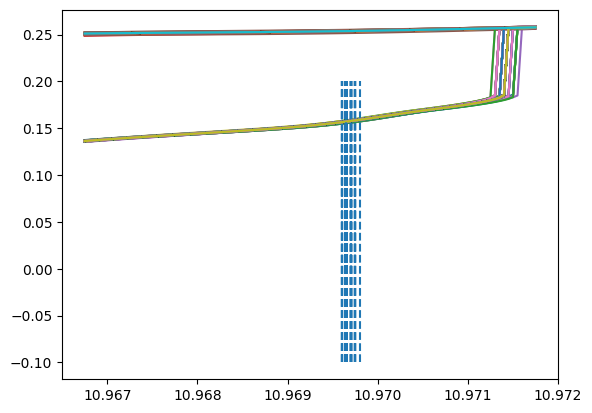

In [25]:
ibetac_jk_ = []
for jdrop in np.arange(nbeta):
    tmp_ = []
    for ibin in np.arange(40):
        print(jdrop, ibin)
    # jdrop = 4
    # ibin = 3
        desc = "jk_"+str(jdrop)+"_40_"+str(ibin)
        
        directory = "fit_params_"+str(Ns)+"c_m"+mass+"_"+desc+"/"
        
        # clean-room Veff.h5 is WINDOWED [iblo, ibhi] (get_potential_jk only wrote the
        # double-well betas). Place each resample's minima_data at its ABSOLUTE ibeta so
        # ibetac stays an absolute index (matches the shooter's dibeta = ibetac_jk - ibetac0).
        # Outside the window -> NaN -> +inf in the objective, so the argmin never selects it.
        lis = np.full((1001, 4), np.nan)
        f = h5py.File(directory+"/Veff.h5", 'r')
        # print( f.keys() )
        for ibeta in ibetas:
            lis[ibeta] = f[str(ibeta)+'/minima_data'][()]
            # tmp = np.loadtxt( directory+"minima_data_"+str(ibeta)+".dat" )
        f.close()

        obj = (lis.T[2] - lis.T[3])**2
        obj = np.where(np.isnan(obj), np.inf, obj)

        ibeta_m_=ibeta_m-1
        ibeta_M_=ibeta_M-1

        ibetac=ibeta_m_
        while ibetac==ibeta_m_:
            ibeta_m_+=1
            ibeta_M_+=1
            ibetac = np.argmin( obj[ibeta_m_:ibeta_M_] ) + ibeta_m_
        if ibeta_m_==ibetac or abs(ibeta_M_-ibetac)<=4:
            print( jdrop, ibin )
            plt.plot( betas, lis.T[0])
            plt.plot( betas, lis.T[1] )
            plt.vlines( (betas[ibetac]), -0.1, 0.2, ls='dashed' )

        tmp_.append( ibetac )
        plt.plot( betas, lis.T[0])
        plt.plot( betas, lis.T[1] )
        plt.vlines( (betas[ibetac]), -0.1, 0.2, ls='dashed' )
    ibetac_jk_.append(tmp_)

plt.show()

In [26]:
ibetac_jk = np.array( ibetac_jk_ )

In [27]:
np.savetxt( "ibetac_jk_mass"+mass+"_"+str(Ns)+".dat", ibetac_jk )

In [28]:
# v16: MEAN betac_ibetac from the mean Veff (argmin (VA-VB)^2 in the bracket). Writes the [betac, ibetac]
# file that hist_spline_jk reads for ibetac0 (its last line = ibetac). Run once per mass (same mass block).
lis_m = np.full((1001, 4), np.nan)
fm = h5py.File("fit_params_"+str(Ns)+"c_m"+mass+"/Veff.h5", 'r')
for ibeta in ibetas:
    lis_m[ibeta] = fm[str(ibeta)+'/minima_data'][()]
fm.close()
obj_m = (lis_m.T[2] - lis_m.T[3])**2
obj_m = np.where(np.isnan(obj_m), np.inf, obj_m)
ibetac_mean = int( np.argmin( obj_m[ibeta_m:ibeta_M] ) + ibeta_m )
print("v16 mean betac:", mass, ibetac_mean, betas[ibetac_mean])
np.savetxt( "betac_ibetac_mass"+mass+"_"+str(Ns)+".dat", [betas[ibetac_mean], ibetac_mean] )

v16 mean betac: 0p2000 793 10.96965


In [29]:
ibetac_jk.size

360

In [30]:
pwd

'/mnt/hdd_barracuda/llnl/reweight/32c_reanalysis/spline_cpp_v16_32c_claude'

In [12]:
betas[ibetac]

np.float64(10.97165)

In [13]:
ibetac

np.int64(833)

In [8]:
# ibeta_m = 775
# ibeta_M = 816

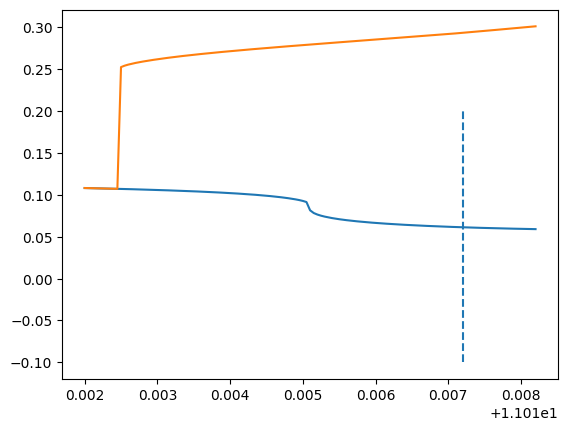

In [9]:
# single-resample inspection (change jdrop/ibin to look at any resample)
jdrop = 3
ibin = 11

desc = "jk_"+str(jdrop)+"_40_"+str(ibin)

directory = "fit_params_"+str(Ns)+"c_m"+mass+"_"+desc+"/"

# clean-room: read the eps-shrunk Veff.h5, absolute-indexed (NaN outside the window)
lis = np.full((1001, 4), np.nan)
f = h5py.File(directory+"/Veff.h5", 'r')
for ibeta in ibetas:
    lis[ibeta] = f[str(ibeta)+'/minima_data'][()]
f.close()

obj = (lis.T[2] - lis.T[3])**2
obj = np.where(np.isnan(obj), np.inf, obj)

ibeta_m_=ibeta_m-1
ibeta_M_=ibeta_M-1

ibetac=ibeta_m_
while ibetac==ibeta_m_:
    ibeta_m_+=1
    ibeta_M_+=1
    ibetac = np.argmin( obj[ibeta_m_:ibeta_M_] ) + ibeta_m_
if ibeta_m_==ibetac or ibeta_M_-1==ibetac:
    print( jdrop, ibin )
    plt.plot( betas, lis.T[0])
    plt.plot( betas, lis.T[1] )
    plt.vlines( (betas[ibetac]), -0.1, 0.2, ls='dashed' )

# plt.vlines( (betas[783]), -0.1, 0.2, ls='dashed' )

plt.plot( betas, lis.T[0])
plt.plot( betas, lis.T[1] )
plt.vlines( (betas[ibetac]), -0.1, 0.2, ls='dashed' )
    # ibetac_jk_.append(tmp_)

In [10]:
ibetac

np.int64(444)

In [11]:
ibeta_m_

428

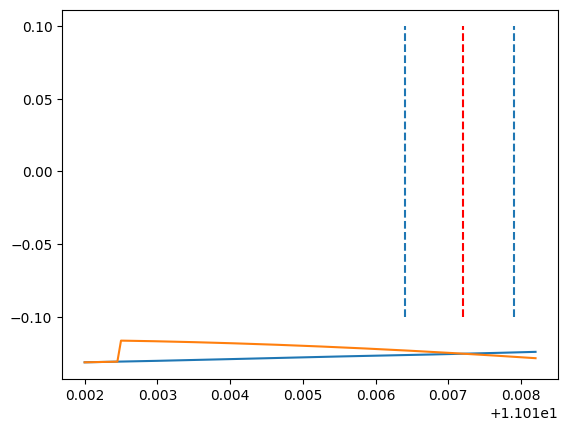

In [12]:
plt.plot( betas, lis.T[2])
plt.plot( betas, lis.T[3] )
plt.vlines( (betas[ibeta_m_], betas[ibeta_M_]), -0.1, 0.1, ls='dashed' )
plt.vlines( (betas[ibetac]), -0.1, 0.1, ls='dashed', color='red' )

In [19]:
ibeta_m, ibetac, ibeta_M

(816, np.int64(833), 858)